# 🚢 Titanic Data Cleaning — Week 2 Project
**Month 2 · Week 2 · Data Handling Pipeline**

---
### Dataset
- Source: Kaggle Titanic (`train.csv`)
- Shape: 891 rows × 12 columns

### Cleaning Pipeline
1. Load & Inspect
2. Data Validation (impossible values → NA)
3. Handle Missing Values (fill strategies)
4. Drop Unnecessary Columns
5. Duplicate Check
6. Outlier Detection & Handling
7. Type Conversions
8. Final Check & Save

## Step 1 — Load & Inspect

Before cleaning anything, understand the dataset:
- `df.shape` → rows × columns
- `df.columns` → column names
- `df.describe()` → statistics
- `df.info()` → dtypes + null counts

In [64]:
# Basic Pre processing checks

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from jedi.debug import print_to_stdout

df = pd.read_csv("data/titanic_raw.csv" , sep= ",")
a1= df.head(10)
a2 = df.describe()
# a3 = df.info()
a4 = df.shape
a5 = df.columns

print(a5)
print(a4)




Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
(891, 12)


## Step 2 — Data Validation (Impossible Values → NA)

Check domain rules **before** filling missing values.  
Invalid values are set to `pd.NA` so they get treated as missing in the next step.

| Column | Rule |
|---|---|
| Age | must be 0–100 |
| Fare | must be ≥ 0 |
| SibSp | must be ≥ 0 |
| Parch | must be ≥ 0 |
| Pclass | only 1, 2, 3 valid |
| Survived | only 0, 1 valid |
| Sex | only male, female |
| Embarked | only S, C, Q |

In [66]:
import pandas as pd

# Data Validation

# Age
df.loc[
    (df["Age"] < 0) | (df["Age"] > 100),
    "Age"
] = pd.NA

# Fare
df.loc[
    df["Fare"] < 0,
    "Fare"
] = pd.NA

# SibSp
df.loc[
    df["SibSp"] < 0,
    "SibSp"
] = pd.NA

# Parch
df.loc[
    df["Parch"] < 0,
    "Parch"
] = pd.NA

# Pclass → only 1,2,3 valid
df.loc[
    ~df["Pclass"].isin([1, 2, 3]),
    "Pclass"
] = pd.NA

# Survived → only 0,1 valid
df.loc[
    ~df["Survived"].isin([0, 1]),
    "Survived"
] = pd.NA

# Sex → only male,female valid
df.loc[
    ~df["Sex"].isin(["male", "female"]),
    "Sex"
] = pd.NA

# Embarked → only S,C,Q valid
df.loc[
    ~df["Embarked"].isin(["S", "C", "Q"]),
    "Embarked"
] = pd.NA

## Step 3 — Handle Missing Values

### Strategy per column

| Column | Strategy | Why |
|---|---|---|
| Age | Group median (Title + Pclass + Sex) | Outliers present; group fill more accurate than global |
| Embarked | Mode | Categorical; 2 rows missing only |
| Fare | Group mean by Pclass | Fare varies significantly by class |
| SibSp / Parch | Fill 0 | No siblings/parents is most logical default |
| Sex | Fill "Unknown" | Cannot assume gender |
| Survived | Fill "Unknown" | Cannot claim alive/dead — keep for EDA only, drop before ML |
| Pclass | Mode | Rare missing; most common class is safe fallback |

> **Note:** Title column is extracted from Name first — used as a grouping key for Age fill.

In [67]:
# Filling Null (Missing Values )
# Create Title column
df["Title"] = df["Name"].str.extract(
    " ([A-Za-z]+)\.",
    expand=False
)

# Age
df["Age"] = df.groupby(
    ["Title", "Pclass", "Sex"]
)["Age"].transform(
    lambda x: x.fillna(x.median())
)

# Embarked
df["Embarked"] = df["Embarked"].fillna(
    df["Embarked"].mode()[0]
)

# Fare
df["Fare"] = df.groupby("Pclass")["Fare"].transform(
    lambda x: x.fillna(x.mean())
)

# SibSp
df["SibSp"] = df["SibSp"].fillna(0)

# Parch
df["Parch"] = df["Parch"].fillna(0)

# Sex
df["Sex"] = df["Sex"].fillna("Unknown")

# Survived
df["Survived"] = df["Survived"].fillna("Unknown")
# Drop the Unknown row if to train an ml model as it is kept only for EDA

# Pclass
df["Pclass"] = df["Pclass"].fillna(
    df["Pclass"].mode()[0]
)

print(df.isnull().sum())
# Here mode fill is great as fare withing class can be differnt type of room normal or luxury do many tiny grp  and p.class mean can be wrng



PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Title            0
dtype: int64


<>:4: SyntaxWarning: invalid escape sequence '\.'
<>:4: SyntaxWarning: invalid escape sequence '\.'
C:\Users\Rupali Waghmare\AppData\Local\Temp\ipykernel_30772\1404762928.py:4: SyntaxWarning: invalid escape sequence '\.'
  " ([A-Za-z]+)\.",


## Step 4 — Drop Unnecessary Columns

**Cabin** is dropped because:
- 687 / 891 = **77% missing** — too high to impute reliably
- Even with cabin number, not enough structure to group-fill meaningfully

> **Note on Survived = "Unknown":** These rows are kept for EDA purposes.  
> Before training any ML model, drop them: `df = df[df["Survived"] != "Unknown"]`

In [68]:
# Dropping unnecessary rows and columns

df.drop("Cabin" , axis=1 , inplace=True)
print(df.isnull().sum())

# Has survived missing value cannot be filled as we cannot claim if some died or is survived as we dont know so we drop the rows with Unknown


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Title          0
dtype: int64


## Step 5 — Duplicate Check & Descriptive Stats

- `df.describe(include="all")` → includes categorical columns (use `include="all"`)
- `df.duplicated().sum()` → count exact duplicate rows

> `include="all"` shows count, unique, top, freq for categorical columns alongside numeric stats.

In [69]:
print(df.describe(include="all")) # include = "all" it also includes category
# sometimes category is useless

print(df.duplicated().sum())

        PassengerId    Survived      Pclass                     Name   Sex  \
count    891.000000  891.000000  891.000000                      891   891   
unique          NaN         NaN         NaN                      891     2   
top             NaN         NaN         NaN  Braund, Mr. Owen Harris  male   
freq            NaN         NaN         NaN                        1   577   
mean     446.000000    0.383838    2.308642                      NaN   NaN   
std      257.353842    0.486592    0.836071                      NaN   NaN   
min        1.000000    0.000000    1.000000                      NaN   NaN   
25%      223.500000    0.000000    2.000000                      NaN   NaN   
50%      446.000000    0.000000    3.000000                      NaN   NaN   
75%      668.500000    1.000000    3.000000                      NaN   NaN   
max      891.000000    1.000000    3.000000                      NaN   NaN   

               Age       SibSp       Parch  Ticket        Fare 

## Step 6 — Outlier Detection & Handling

### Visual method → Boxplot
Boxplot shows IQR box + whiskers. Points beyond whiskers = outliers.

### Statistical method → IQR
```
lower_bound = Q1 - 1.5 × IQR
upper_bound = Q3 + 1.5 × IQR
```

### Handling decision for Fare (right-skewed)

| Option | Why rejected / chosen |
|---|---|
| Remove | ❌ Lose important high-fare passengers (1st class detail) |
| Cap | ❌ Distorts real values (e.g. 512 capped to 100 = loss of business value) |
| Keep as-is | ❌ Skews model training |
| **Log transform** | ✅ Compresses scale, normalises distribution, preserves all rows |

> `np.log1p(x)` = `log(1 + x)` — handles Fare = 0 safely (log(0) = -inf, log(1) = 0)

**Age** — not transformed. Distribution is approximately normal after group-median fill.

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'Title'],
      dtype='object')
0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
5    26.0
6    54.0
7     2.0
8    27.0
9    14.0
Name: Age, dtype: float64


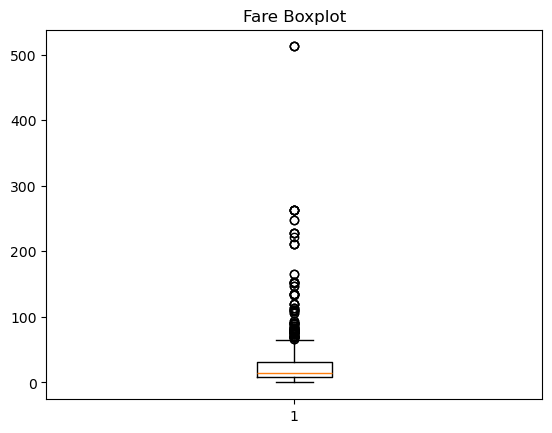

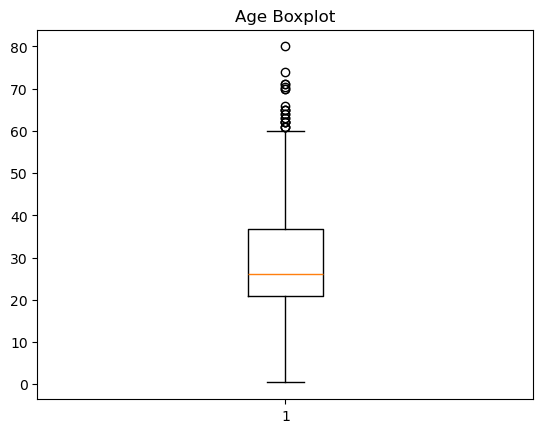

     PassengerId  Survived  Pclass  \
1              2       1.0     1.0   
27            28       0.0     1.0   
31            32       1.0     1.0   
34            35       0.0     1.0   
52            53       1.0     1.0   
61            62       1.0     1.0   
62            63       0.0     1.0   
72            73       0.0     2.0   
88            89       1.0     1.0   
102          103       0.0     1.0   

                                                  Name     Sex   Age  SibSp  \
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0    1.0   
27                      Fortune, Mr. Charles Alexander    male  19.0    3.0   
31      Spencer, Mrs. William Augustus (Marie Eugenie)  female  41.5    1.0   
34                             Meyer, Mr. Edgar Joseph    male  28.0    1.0   
52            Harper, Mrs. Henry Sleeper (Myna Haxtun)  female  49.0    1.0   
61                                 Icard, Miss. Amelie  female  38.0    0.0   
62                         H

In [70]:
# Outlier Detection

print(df.columns)

print(df["Age"].head(10))

# Visual Outlier

# Fare
plt.boxplot(df["Fare"])
plt.title("Fare Boxplot")
plt.show()

# Age
plt.boxplot(df["Age"])
plt.title("Age Boxplot")
plt.show()

# IQR method

Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Fare"] < lower_bound) | (df["Fare"] > upper_bound)]
print(outliers.head(10))


# As here from all outlier handling method I choose log transform
# 1.remove -> cant be done we can lose important detail
# 2.cap -> may lose value as Ex. some room cost 512 but after capping it reduced to 100 so loss of original data or reduce business value
# 3.keep -> not good approach for training of any model
# 4. log transform -> it will make highly right skewed data normalized and close good for visualizing and model training

# Handling only fare as it is only right skewed age is better normally
df["Log_Fare"] = np.log1p(df["Fare"])


## Step 7 — Type Conversions

Convert columns to their correct dtype for memory efficiency and ML compatibility.

| Type | Columns | Reason |
|---|---|---|
| `int64` | PassengerId, Age, SibSp, Parch | Whole numbers only |
| `float64` | Fare, Log_Fare | Decimal values |
| `category` | Survived, Pclass, Sex, Embarked | Finite set of values — saves memory |

> **When to use `pd.to_numeric(errors='coerce')`:** Only when column has mixed types (e.g. "25", "N/A", 30). Converts bad values to NaN automatically.

In [71]:
# Type Conversion

print(df.columns)
print(df["PassengerId"].head(10))

# int64
for col in ["PassengerId" , "Age" , "SibSp" , "Parch"]:
    df[col] = df[col].astype(int)

# float
for col in ["Fare" , "Log_Fare"]:
    df[col] = df[col].astype(float)

# category
for col in ["Survived" , "Pclass" , "Sex" , "Embarked"]:
    df[col] = df[col].astype("category")

# use pd.to_numeric(errors="coerce) here only use when data is messy

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'Title', 'Log_Fare'],
      dtype='object')
0     1
1     2
2     3
3     4
4     5
5     6
6     7
7     8
8     9
9    10
Name: PassengerId, dtype: int64


## Step 8 — Final Check & Save

Verify the entire cleaning pipeline worked before saving.

In [ ]:
# ✅ Final verification
print("Shape:", df.shape)
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nTotal missing cells:", df.isnull().sum().sum())
print("\nFinal dtypes:")
print(df.dtypes)
print("\nFirst 5 rows of cleaned data:")
display(df.head())

In [72]:
df.to_csv("data/titanic_cleaned.csv" , index = False)

---
> **Week 2 Project complete.** Dataset cleaned end-to-end and saved to `data/titanic_cleaned.csv`